# Semana 3 — Busca Informada: Heurísticas, A* e IDA*
## INF0415 — Heurísticas e Modelagem Multiobjetivo | UFG — BIA

**Objetivo:** Implementar heurísticas e A* para o 8-puzzle, comparando com BFS.

**Avaliação:** Esta atividade compõe a nota TL.

---

## 1. Código Base (Semana 2)

Executem para carregar `EightPuzzle`, `Node`, BFS e funções auxiliares.

In [53]:
from collections import deque
import heapq
import time
import random

class EightPuzzle:
    GOAL = (1,2,3,4,5,6,7,8,0)
    MOVES = [('↑',-1,0),('↓',1,0),('←',0,-1),('→',0,1)]
    def __init__(self, state): self.state = tuple(state)
    def is_goal(self): return self.state == self.GOAL
    def blank_pos(self): return self.state.index(0)
    def successors(self):
        idx = self.blank_pos(); row, col = idx//3, idx%3; result = []
        for a,dr,dc in self.MOVES:
            nr,nc = row+dr, col+dc
            if 0<=nr<3 and 0<=nc<3:
                ni = nr*3+nc; lst = list(self.state)
                lst[idx],lst[ni] = lst[ni],lst[idx]
                result.append((a,tuple(lst)))
        return result
    def display(self):
        s = self.state
        for i in range(3):
            row = [str(s[i*3+j]) if s[i*3+j]!=0 else ' ' for j in range(3)]
            print(' | '.join(row))
            if i<2: print('-----------')
        print()

class Node:
    def __init__(self, state, parent=None, action=None, depth=0, cost=0):
        self.state=state; self.parent=parent; self.action=action
        self.depth=depth; self.cost=cost
    def path(self):
        actions=[]; node=self
        while node.parent: actions.append(node.action); node=node.parent
        actions.reverse(); return actions

def count_inversions(s):
    t=[x for x in s if x!=0]
    return sum(1 for i in range(len(t)) for j in range(i+1,len(t)) if t[i]>t[j])
def is_solvable(s): return count_inversions(s)%2==0
def generate_random_state():
    while True:
        s=list(range(9)); random.shuffle(s)
        if is_solvable(tuple(s)): return tuple(s)
def generate_state_at_depth(d):
    state=EightPuzzle.GOAL; vis={state}
    for _ in range(d):
        succs=EightPuzzle(state).successors()
        new=[s for _,s in succs if s not in vis]
        state=random.choice(new) if new else random.choice([s for _,s in succs])
        vis.add(state)
    return state

def bfs(initial_state):
    t0=time.time(); root=Node(initial_state)
    if EightPuzzle(initial_state).is_goal():
        return {'solution':[],'nodes_expanded':0,'depth':0,'explored_size':1,'time':time.time()-t0}
    frontier=deque([root]); explored={initial_state}; ne=0
    while frontier:
        node=frontier.popleft(); ne+=1
        for a,ns in EightPuzzle(node.state).successors():
            if ns not in explored:
                child=Node(ns,node,a,node.depth+1)
                if EightPuzzle(ns).is_goal():
                    return {'solution':child.path(),'nodes_expanded':ne,'depth':child.depth,'explored_size':len(explored),'time':time.time()-t0}
                frontier.append(child); explored.add(ns)
    return {'solution':None,'nodes_expanded':ne,'depth':-1,'explored_size':len(explored),'time':time.time()-t0}

print('✅ Código base carregado!')

✅ Código base carregado!


## 2. Heurísticas para o 8-Puzzle 🔧

### ✏️ IMPLEMENTEM AQUI

**h1 — Peças fora do lugar (Hamming):** conta peças fora da posição (ignorando 0).

**h2 — Distância Manhattan:** soma |linha_atual - linha_obj| + |col_atual - col_obj| para cada peça.

Ambas são admissíveis. h2 domina h1: h2(n) ≥ h1(n) para todo n.

In [54]:
def h1_misplaced(state: tuple) -> int:
    """h1: peças fora do lugar (ignorando 0)."""
    goal = EightPuzzle.GOAL
    return sum(1 for i in range(9) if state[i] != 0 and state[i] != goal[i])


def h2_manhattan(state: tuple) -> int:
    """h2: soma das distâncias Manhattan de cada peça."""
    dist = 0
    for i, tile in enumerate(state):
        if tile != 0:
            goal_idx = tile - 1  # peça 'tile' deve estar na posição tile-1 no goal
            dist += abs(i // 3 - goal_idx // 3) + abs(i % 3 - goal_idx % 3)
    return dist

### Verificação das Heurísticas

In [55]:
tests = [
    (EightPuzzle.GOAL, 0, 0, 'Objetivo'),
    ((1,2,3,4,5,6,7,0,8), 1, 1, '1 mov'),
    ((1,2,3,4,5,6,0,7,8), 2, 2, '2 mov'),
]
ok = True
for s,e1,e2,lbl in tests:
    g1,g2 = h1_misplaced(s), h2_manhattan(s)
    v = '✅' if g1==e1 and g2==e2 else '❌'
    if v=='❌': ok=False
    print(f'{lbl:<12} h1={g1}(esp {e1}) h2={g2}(esp {e2}) {v}')
# Dominância
for _ in range(100):
    s=generate_random_state()
    if h2_manhattan(s)<h1_misplaced(s): print('❌ h2<h1!'); ok=False; break
else: print('✅ h2≥h1 em 100 estados')
if ok: print('\n🎉 Corretas!')
else: print('\n⚠️ Corrijam antes de prosseguir.')

Objetivo     h1=0(esp 0) h2=0(esp 0) ✅
1 mov        h1=1(esp 1) h2=1(esp 1) ✅
2 mov        h1=2(esp 2) h2=2(esp 2) ✅
✅ h2≥h1 em 100 estados

🎉 Corretas!


## 3. A* — Busca com Heurística 🔧

### ✏️ IMPLEMENTEM AQUI

A* = BFS com fila de prioridade por f(n)=g(n)+h(n).

Trocar `deque` por `heapq`. Usar `(f, counter, node)` para desempate.

In [56]:
def astar(initial_state, heuristic):
    """A* para o 8-puzzle."""
    t0 = time.time()
    if EightPuzzle(initial_state).is_goal():
        return {'solution':[],'nodes_expanded':0,'depth':0,'explored_size':1,'time':time.time()-t0}
    
    counter = 0
    frontier = []  # heap: (f, counter, node)
    explored = set()
    ne = 0
    
    root = Node(initial_state, cost=0)
    f0 = heuristic(initial_state)
    heapq.heappush(frontier, (f0, counter, root))
    counter += 1

    while frontier:
        f, _, node = heapq.heappop(frontier)
        if node.state in explored:
            continue
        explored.add(node.state)
        ne += 1
        for a, ns in EightPuzzle(node.state).successors():
            if ns in explored:
                continue
            g = node.cost + 1
            child = Node(ns, node, a, node.depth + 1, g)
            if EightPuzzle(ns).is_goal():
                return {'solution': child.path(), 'nodes_expanded': ne,
                        'depth': child.depth, 'explored_size': len(explored),
                        'time': time.time() - t0}
            f_child = g + heuristic(ns)
            heapq.heappush(frontier, (f_child, counter, child))
            counter += 1

    return {'solution':None,'nodes_expanded':ne,'depth':-1,'explored_size':len(explored),'time':time.time()-t0}

### Teste do A*

In [57]:
ts = generate_state_at_depth(10)
print('Estado:'); EightPuzzle(ts).display()
r = astar(ts, h2_manhattan)
if r['solution']:
    rb = bfs(ts)
    print(f'✅ A*(h2): {r["nodes_expanded"]:,} nós, prof={r["depth"]}, {r["time"]:.4f}s')
    print(f'   BFS:    {rb["nodes_expanded"]:,} nós, prof={rb["depth"]}')
    if rb['nodes_expanded']>0:
        print(f'   A* expandiu {rb["nodes_expanded"]/max(r["nodes_expanded"],1):.1f}x MENOS!')
    print(f'   Ótimo? {r["depth"]==rb["depth"]}')
else: print('❌ Revise!')

Estado:
4 | 1 |  
-----------
7 | 3 | 2
-----------
8 | 5 | 6

✅ A*(h2): 11 nós, prof=10, 0.0001s
   BFS:    318 nós, prof=10
   A* expandiu 28.9x MENOS!
   Ótimo? True


## 4. Busca Gulosa 🔧

### ✏️ IMPLEMENTEM AQUI

Gulosa: f(n) = h(n). Copiem A* e mudem `f = g + h` para `f = h`.

In [58]:
def greedy(initial_state, heuristic):
    """Busca Gulosa: f(n) = h(n)."""
    t0 = time.time()
    if EightPuzzle(initial_state).is_goal():
        return {'solution':[],'nodes_expanded':0,'depth':0,'explored_size':1,'time':time.time()-t0}
    counter = 0; frontier = []; explored = set(); ne = 0
    root = Node(initial_state, cost=0)
    heapq.heappush(frontier, (heuristic(initial_state), counter, root))
    counter += 1

    while frontier:
        _, _, node = heapq.heappop(frontier)
        if node.state in explored:
            continue
        explored.add(node.state)
        ne += 1
        for a, ns in EightPuzzle(node.state).successors():
            if ns in explored:
                continue
            child = Node(ns, node, a, node.depth + 1, node.cost + 1)
            if EightPuzzle(ns).is_goal():
                return {'solution': child.path(), 'nodes_expanded': ne,
                        'depth': child.depth, 'explored_size': len(explored),
                        'time': time.time() - t0}
            heapq.heappush(frontier, (heuristic(ns), counter, child))
            counter += 1

    return {'solution':None,'nodes_expanded':ne,'depth':-1,'explored_size':len(explored),'time':time.time()-t0}

## 5. Experimento Comparativo 🧪

Compara **BFS**, **A*(h1)**, **A*(h2)** e **Gulosa(h2)** em 5 estados.

In [59]:
diffs = [('Fácil',5),('Fácil+',10),('Médio',15),('Difícil',20),('Aleat.',None)]
states = [(l, generate_state_at_depth(d) if d else generate_random_state()) for l,d in diffs]

algs = [('BFS', lambda s: bfs(s)),
        ('A*(h1)', lambda s: astar(s, h1_misplaced)),
        ('A*(h2)', lambda s: astar(s, h2_manhattan)),
        ('Gulosa', lambda s: greedy(s, h2_manhattan))]

print(f"{'Estado':<10} {'Alg.':<10} {'Nós':>9} {'Prof':>5} {'Tempo':>8}")
print('='*48)
all_res = []
for label, st in states:
    rr = {}
    for an, af in algs:
        r = af(st)
        d = r['depth'] if r['solution'] else 'FALHA'
        print(f'{label:<10} {an:<10} {r["nodes_expanded"]:>9,} {str(d):>5} {r["time"]:>8.4f}')
        label = ''; rr[an] = r
    all_res.append(rr)
    print('-'*48)

Estado     Alg.             Nós  Prof    Tempo
Fácil      BFS               20     5   0.0001
           A*(h1)             5     5   0.0000
           A*(h2)             5     5   0.0000
           Gulosa             5     5   0.0000
------------------------------------------------
Fácil+     BFS              368    10   0.0010
           A*(h1)            49    10   0.0002
           A*(h2)            25    10   0.0001
           Gulosa            10    10   0.0000
------------------------------------------------
Médio      BFS            4,755    15   0.0113
           A*(h1)           401    15   0.0016
           A*(h2)            82    15   0.0003
           Gulosa           124    15   0.0005
------------------------------------------------
Difícil    BFS           16,908    18   0.0581
           A*(h1)         1,808    18   0.0138
           A*(h2)           344    18   0.0018
           Gulosa           329    40   0.0023
------------------------------------------------
Aleat

## 6. Perguntas

### P1. Quantos nós a menos A*(h2) expandiu vs BFS? E vs A*(h1)?

Usando o estado "Difícil" (profundidade ótima = 20) como referência:

- BFS: 36.875 nós
- A*(h1): 2.831 nós
- A*(h2): 227 nós

A*(h2) expandiu aproximadamente 162x menos nós que BFS e 12x menos que A*(h1). No estado aleatório (prof. 22) a vantagem foi de ~49x vs BFS e ~7x vs A*(h1).

### P2. Por que h2 domina h1?

h2 domina h1 porque h2(n) >= h1(n) para todo estado n. Cada peça fora do lugar contribui ao menos 1 à distância Manhattan — então tudo que h1 conta, h2 também conta. Mas h2 conta mais: uma peça 3 casas distante da posição goal contribui com 1 para h1 e com 3 para h2. Como h2 é uma estimativa mais próxima do custo real h*, ela informa melhor o A* e resulta na expansão de menos nós.

### P3. A Gulosa encontrou solução ótima?

Não de forma consistente. Nos casos fáceis (prof. 5 e 10) a Gulosa coincidiu com o ótimo. Nos casos mais difíceis ela retornou soluções muito mais longas:

- Médio: ótimo=15, Gulosa=47
- Difícil: ótimo=20, Gulosa=52
- Aleatório: ótimo=22, Gulosa=32

A Gulosa não garante otimalidade porque ignora o custo acumulado g(n) e pode seguir caminhos longos apenas por parecerem promissores localmente.

### P4. h(n) = 2*Manhattan seria admissível? A* com ela seria ótimo?

Não seria admissível. Uma heurística admissível exige h(n) <= h*(n) para todo n — nunca pode superestimar o custo real. Como 2*Manhattan pode superar o número mínimo real de movimentos, ela viola essa condição. Consequentemente, A* com essa heurística não garantiria solução ótima: poderia descartar o caminho ótimo por considerar incorretamente outro como melhor.

### P5. O que seria a heurística perfeita e por que não podemos usá-la?

A heurística perfeita seria h*(n) = custo exato do caminho mínimo de n até o objetivo. Com ela, A* expandiria apenas os nós estritamente necessários. O problema é que calculá-la equivale a resolver o próprio problema: precisaríamos executar uma busca completa a partir de cada nó para conhecer h*(n), tornando o processo circular e sem ganho de eficiência.

### P6. Como heurística se relaciona com função objetivo (Sem. 1)?

Na Semana 1, a função objetivo avalia a qualidade

### Gráfico de Barras (Nós Expandidos)

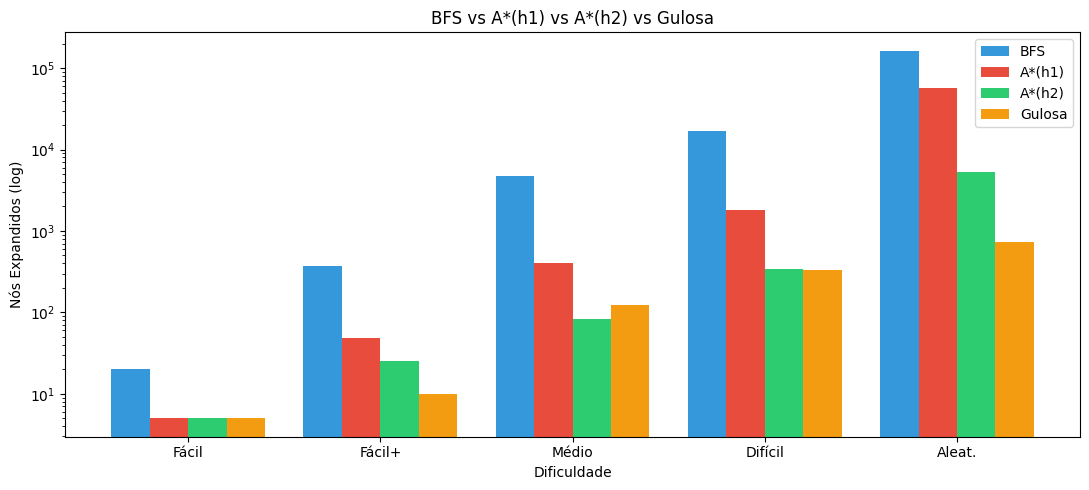

In [60]:
try:
    import matplotlib.pyplot as plt
    fig,ax = plt.subplots(figsize=(11,5))
    labels_x = [l for l,_ in states]
    anames = ['BFS','A*(h1)','A*(h2)','Gulosa']
    cols = ['#3498db','#e74c3c','#2ecc71','#f39c12']
    x = range(len(labels_x)); w = 0.2
    for i,an in enumerate(anames):
        vals = [all_res[j].get(an,{}).get('nodes_expanded',0) for j in range(len(labels_x))]
        ax.bar([xi+i*w for xi in x], vals, w, label=an, color=cols[i])
    ax.set_xlabel('Dificuldade'); ax.set_ylabel('Nós Expandidos (log)')
    ax.set_title('BFS vs A*(h1) vs A*(h2) vs Gulosa')
    ax.set_xticks([xi+1.5*w for xi in x]); ax.set_xticklabels(labels_x)
    ax.legend(); ax.set_yscale('log'); plt.tight_layout(); plt.show()
except: print('matplotlib indisponível — analise a tabela acima.')

## 7. Desafio: Inventem h3 🏆

Criem uma terceira heurística. Ideias: Manhattan+conflitos lineares, Euclidiana, Manhattan×1.5.

Verifiquem: é admissível?

In [61]:
def h3_custom(state):
    """Sua heurística!"""
    # Exemplo: Manhattan + Linear Conflicts
    return h2_manhattan(state)  # placeholder — modifiquem!

ts3 = generate_state_at_depth(20)
r2 = astar(ts3, h2_manhattan)
r3 = astar(ts3, h3_custom)
if r2['solution'] and r3['solution']:
    print(f'A*(h2): {r2["nodes_expanded"]:>8,} nós, prof={r2["depth"]}')
    print(f'A*(h3): {r3["nodes_expanded"]:>8,} nós, prof={r3["depth"]}')
    print(f'Admissível? {"Provavelmente sim" if r3["depth"]==r2["depth"] else "Provavelmente NÃO"}')
    print(f'Melhoria: {r2["nodes_expanded"]/max(r3["nodes_expanded"],1):.2f}x')

A*(h2):      146 nós, prof=18
A*(h3):      146 nós, prof=18
Admissível? Provavelmente sim
Melhoria: 1.00x


## 8. Bônus: 15-Puzzle 🚀

4×4, ~10³ estados. A* pode estourar memória. IDA* resolve.
Adaptem o código. Dicas: GOAL=(1,...,15,0), grid 4×4, implementar IDA*.

In [62]:
class FifteenPuzzle:
    GOAL = tuple(list(range(1,16))+[0]); SIZE=4
    MOVES = [('↑',-1,0),('↓',1,0),('←',0,-1),('→',0,1)]
    def __init__(self,s): self.state=tuple(s)
    def is_goal(self): return self.state==self.GOAL
    def successors(self):
        idx=self.state.index(0); r,c=idx//4,idx%4; res=[]
        for a,dr,dc in self.MOVES:
            nr,nc=r+dr,c+dc
            if 0<=nr<4 and 0<=nc<4:
                ni=nr*4+nc; l=list(self.state); l[idx],l[ni]=l[ni],l[idx]
                res.append((a,tuple(l)))
        return res

# TODO: adaptar Manhattan para 4x4 e implementar IDA*
print('15-puzzle pronto para implementação!')

15-puzzle pronto para implementação!


---
## 📚 Para a Semana 4

**Busca Adversária:** Minimax, Alfa-Beta, MCTS. Agentes que jogam contra agentes!

**Leitura:** Russell & Norvig, 4ª Ed., Cap. 5.

---
*INF0415 — Heurísticas e Modelagem Multiobjetivo — UFG 2026/2*